## **SEGMENTAÇÃO DE CLIENTES**

### Projeto de ciência de dados

## **Problema de negócio:**

Desenvolver um sistema inteligente que utilize técnicas avançadas de análise de dados para identificar e categorizar grupos de clientes com características semelhantes, utilizando o algoritmo de clustering não-supervisionado: **K-Means**.

O modelo propõe apoiar o time de negócio, visando melhorar significativamente as estratégias de marketing e garantindo que cada cliente receba uma experiência única e relevante.

isso irá aprimorar as comunicações e ofertas, permitindo uma abordagem personalizada e eficiente.

## **Bibliotecas:**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from itertools import combinations              # cria combinações possíveis entre variáveis
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## **Entendimento dos dados**

O dataset contém informações de 200 clientes, com os seguintes atributos:

**- CustomerID (variável numérica):** Identificador único atribuído a cada cliente.

**- Gender (variável categórica):** Gênero do cliente.

**- Age (variável numérica):** Idade do cliente.

**- Annual Income-k$ (variável numérica):** Renda anual do cliente em milhares de dólares.

**- Spending Score de 1 a100 (variável numérica):** Pontuação atribuída pelo shopping com base no comportamento e padrão de gastos do cliente.

In [2]:
df = pd.read_csv(r"E:\MAYLSON - CIENCIAS DE DADOS\Ciencia de Dados\projeto_M33\Mall_Customers.csv")

df_original = df.copy()   # backup da base bruta

df = df.drop(columns=['CustomerID'])

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## **Análise exploratória de dados (EDA)**

Nessa etapa analisa-se o dataset, buscando entender as principais características das variáveis e a distribuição dos dados.

Busca-se identificar padrões através de estatísticas descritivas 

e também verificar a presença de valores ausentes ou inconsistências que precisem ser tratadas.

In [3]:
#profile = ProfileReport(df, title="EDA - Clientes Shopping", explorative=True)
#profile.to_file("relatorio_profiling.html")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


### o dataset não contém valores faltantes (NaN). 

In [5]:
# estatísticas descritivas das variáveis numéricas
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


## **Distribuição das variáveis**

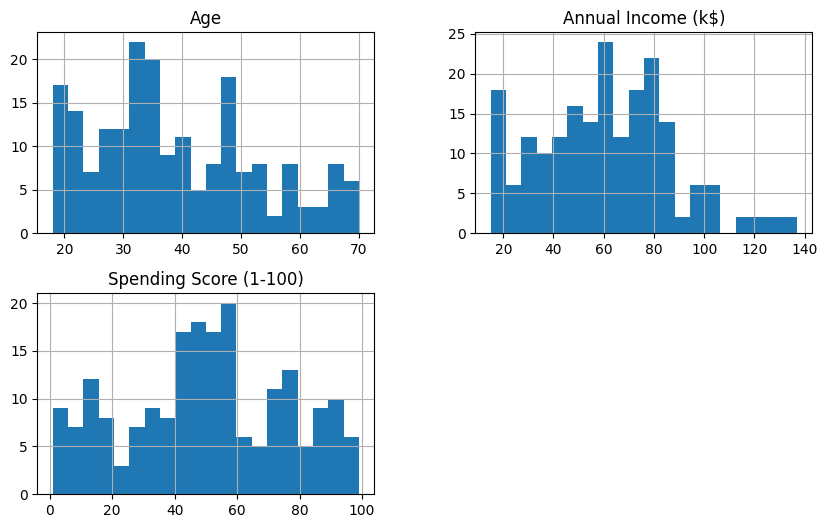

In [6]:
df.hist(bins=20, figsize=(10,6))

plt.show()

### Distribuição de **idade:**

idade média **adultos** de ~39 anos , mas com clientes mais jovens de 18 anos e mais velhos de 70 anos.

### Distribuição de **renda anual:**

renda anual média **espalhada** de k$ 60.5, com clientes com renda anual menor de k$ 15.0 e clientes com renda anual maior de k$ 137.0.

### Distribuição do **score (0 a 100):**

score interno médio de 50 pontos, mas com pontuações mínimas de 1 ponto e clientes com pontuações de 99 pontos.

### esses valores parecem normais e reais, sem valores considerados estranhos na base.

## Análise de Gênero (variável categórica)

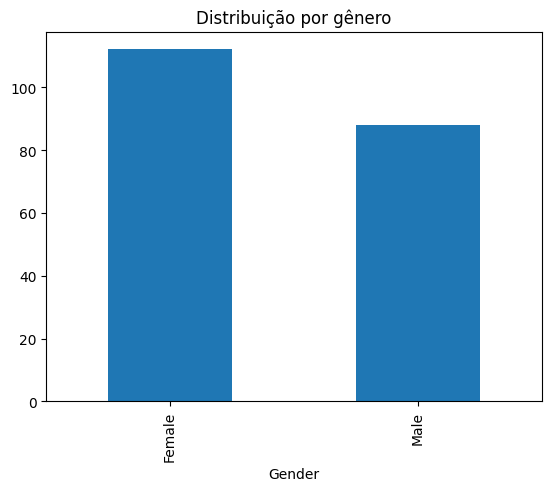

In [7]:
df['Gender'].value_counts().plot(kind='bar')
plt.title('Distribuição por gênero')
plt.show()

In [8]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts(normalize=True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

#### Analisando a distribuição de clientes por gênero, observa-se um maior número de 

#### mulheres, sendo 112 no total, representando 56% da base.

#### enquanto homens são 88 no total, representando 44% da base.

## **Matriz de correlação**

nessa etapa analisamos as relações entre idade, renda e score, ajudando a entender o comportameto dos clientes.

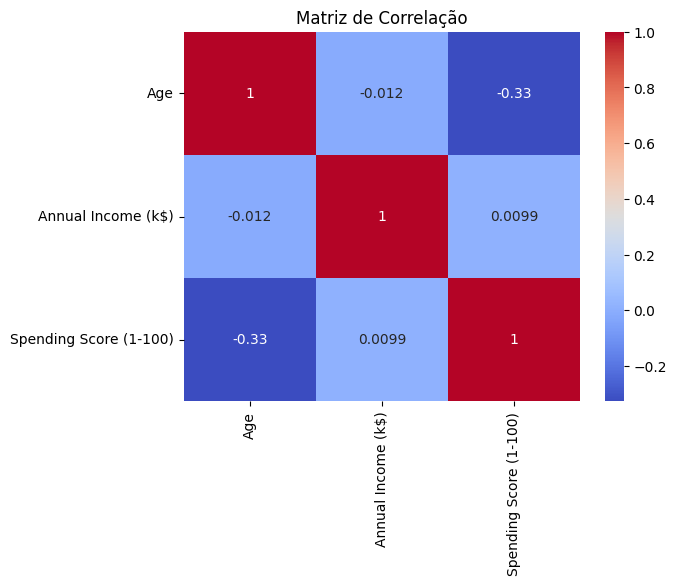

In [10]:
corr = df[['Age',
           'Annual Income (k$)',
           'Spending Score (1-100)'
]].corr()


sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title('Matriz de Correlação')
plt.show()

In [11]:
corr

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


#### correlação fraca negativa entre idade e score de ≈ -0.32, indica que clientes mais jovens tendem a ter maior spending score,

#### o que faz sentido em contexto de shopping,

#### em termos de correlação linear, as variáveis pouco se relacionam, mas isso não significa que não existam padrões,

#### ou seja, mesmo sem correlação forte, podem existir grupos bem definidos, pois o método de clusterização encontra padrões de agrupamento no espaço multidimensional.

## **Interações entre variáveis numéricas**

nessa etapa busca-se visualizar padrões de comportamento.

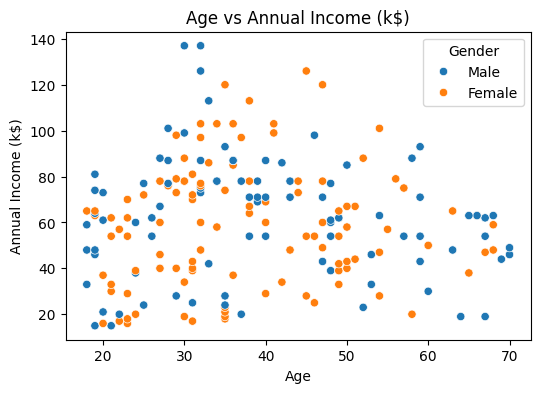

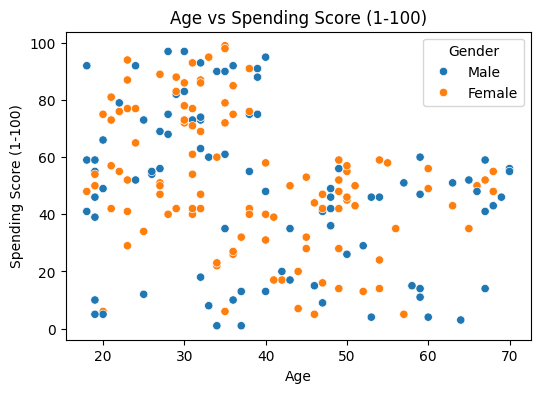

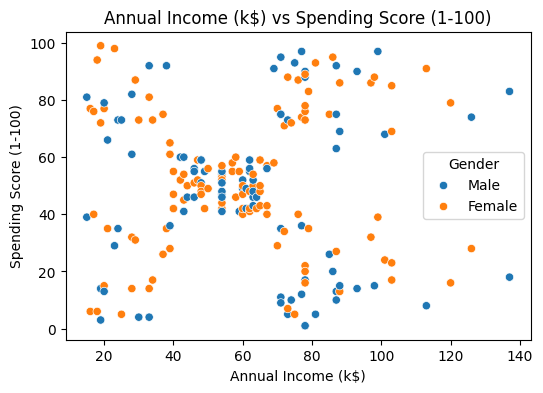

In [12]:
# lista de variáveis numéricas
cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# gerar todas as combinações de 2 em 2
pairs = list(combinations(cols, 2))


for x, y in pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=x, y=y, hue='Gender', data=df)
    plt.title(f'{x} vs {y}')
    plt.show()

#### não há relação clara entre idade de renda anual, por isso correlação de ~0,01.

#### jovens adultos até 40 anos gastam mais que os indivíduos acima dessa idade.

#### na relação renda anual e score foi identificado diferentes padrões por faixa de renda e presença de clientes de alto e baixo score em todas as rendas:

#### Perfis:

- clientes de baixo valor: renda baixa + score baixo,

- clientes impulsivos: renda baixa + score alto,

- clientes padrão: renda média + score médio,

- clientes premium: renda alta + score alto,

- clientes com potencial: renda alta + score baixo.

#### conclui-se nesta etapa que mesmo com correlação baixa e dados aparentemente bagunçados, 

#### consegue-se identificar estrutura de clusters latente no espaço renda vs score

## Análise da qualidade dos dados

In [13]:
print("\nDuplicados:")
print(df.duplicated().sum())


Duplicados:
0


## **Conclusões da análise exploratória de dados**

A análise exploratória revelou que a base de clientes apresenta dados consistentes, sem valores ausentes ou outliers evidentes, com distribuições plausíveis para idade, renda anual e score de gasto.

Apesar da baixa correlação, a análise visual por meio de gráficos de dispersão revelou padrões claros de agrupamento, especialmente entre renda anual e spending score, indicando a presença de possíveis segmentos distintos de clientes.

Esses achados sugerem que a base é adequada para aplicação de técnicas de clusterização, como o algoritmo K-Means, com potencial para identificar perfis de clientes com comportamentos distintos de consumo.

## **Pré-processamento**

## **Escalonamento das variáveis**

Como o K-means usa distância (euclidiana), sem escalonamento, a variável com maior escala domina o cálculo da distância, 

resultando em clusters distorcidos.

#### nessa etapa, serão priorizadas as variáveis: **renda e spending score** por representarem diretamente valor e comportamento de consumo, 

#### que são os principais drivers de segmentação no contexto de varejo. 

#### Posteriormente será testado a inclusão da idade como variável complementar para avaliar possíveis refinamentos nos clusters.

In [15]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## **Elbow method** - método do cotovelo

o elbow trás o melhor ponto da inércia, onde para de trazer ganho relevante, sugerindo o número ideal de k

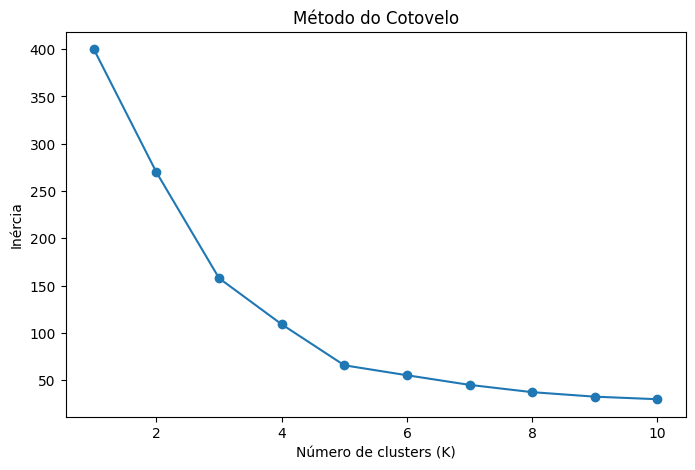

In [18]:
# lista para armazenar as inércias (somando as distâncias dentro dos clusters)
inercia = []

# número de clusters (intervalo de k)
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)             # inercia = erro

#plotando o gráfico
plt.figure(figsize=(8,5))
plt.plot(k_range, inercia, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

#### segundo o método do Cotovelo, indica estabilização da inércia em torno de 5 clusters.

## **Validação quantitativa de clusters - Silhouette score**

essa métrica avalia duas coisas:

**Coesão:** quão próximos os pontos estão do próprio cluster.

**Separação:** quão longe estão dos outros clusters

In [20]:
# silhouette score
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    print(f"K={k} | Silhouette Score = {score:.2f}")

K=2 | Silhouette Score = 0.32
K=3 | Silhouette Score = 0.47
K=4 | Silhouette Score = 0.49
K=5 | Silhouette Score = 0.55


#### k=5 tem o maior valor (0.55), isso significa clusters mais coesos e melhor separação entre grupos,

#### sendo portanto escolhido como o número ideal de clusters para a segmentação.

## **Modelagem**

## **Treinamento KMeans**

nessa etapa, estrutura-se o treinamento do modelo.

In [26]:
# criando o modelo
kmeans = KMeans(n_clusters=5, n_init=20, random_state=42)

# treinando o k-means
clusters = kmeans.fit_predict(X_scaled)

# adiciona os clusters ao DataFrame
df['cluster'] = clusters

## **Clusters**

nessa etapa visualiza-se os clusters através de um gráfico de dispersão (Scatter)

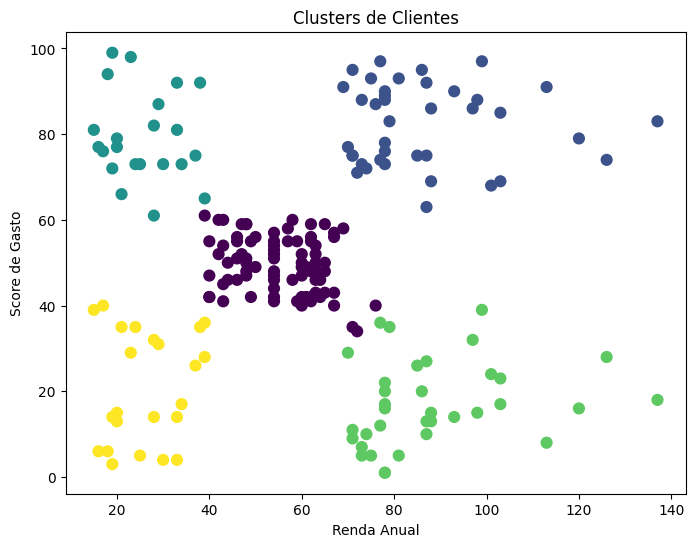

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['cluster'],
    cmap='viridis',
    s=60
)

plt.xlabel('Renda Anual')
plt.ylabel('Score de Gasto')
plt.title('Clusters de Clientes')

# salvando gráfico como .png
plt.savefig('cluster_clientes.png')

plt.show()

## **Centróides**

Como o KMeans foi treinado com dados escalados, é preciso voltar os centróides para a escala original para fazer sentido para o negócio.

In [28]:
# Revertendo a padronização para ver os centroides em unidades originais
centroides = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(
    centroides,
    columns=['Income', 'Score']
)

centroids_df

,Income,Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


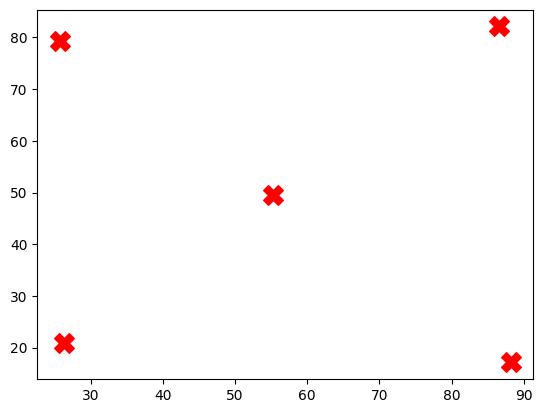

In [36]:
# gráfico
plt.scatter(
    centroids_df['Income'],
    centroids_df['Score'],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

# salvando imagem
plt.savefig('centroids.png')

In [42]:
df['cluster'] = clusters

perfil_clusters = df.groupby('cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean',
    'cluster': 'count'
}).rename(columns={
    'Age': 'idade_media',
    'Annual Income (k$)': 'renda_media',
    'Spending Score (1-100)': 'score_medio',
    'cluster': 'qtd_clientes'
})

perfil_clusters

,idade_media,renda_media,score_medio,qtd_clientes
cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23


#### grupo 0 - **indivíduos mais velhos de renda média e gasto médio:** clientes de médio padrão e comportamento equilibrado.

#### grupo 1 - **indivíduos adultos de renda alta e gasto alto: grupo que gera mais valor.** Clientes premium.

#### grupo 2 - **indivíduos mais jovens de renda baixa e gasto alto:** indivíduos que gastam muito, mesmo com renda menor.

#### grupo 3 - **indivíduos mais velhos de renda alta e gasto baixo: grupo que precisa de ação de marketing.** Clientes com potencial de gerar crescimento de receita.

#### grupo 4 - **indivíduos mais velhos de renda baixa e gasto baixo: grupo que gera menos valor.** Clientes de baixo valor.

## **Conclusões**

Este projeto teve como objetivo segmentar os clientes de um shopping com base em comportamento de consumo, utilizando técnicas de clusterização (K-Means).

Após análise exploratória completa, foram selecionadas as variáveis renda anual e spending score por apresentarem melhor capacidade de separação e interpretação de negócio.

A escolha de K = 5 clusters foi validada por: Método do Elbow e Métrica de Silhouette Score (≈ 0.55), indicando boa separação entre os grupos.

## **Principais Resultados**

Foram identificados 5 perfis claros de clientes:

Clientes Premium - Alta renda e alto consumo: principal fonte de receita e foco de retenção

Clientes de Alto Potencial - Alta renda, mas baixo consumo: oportunidade de aumento de receita com campanhas direcionadas

Clientes de Alto Consumo com Baixa Renda - Alto engajamento, mesmo com menor poder aquisitivo: público sensível a promoções e parcelamentos

Clientes de Perfil Médio - Consumo e renda moderados:  base estável do negócio

Clientes de Baixo Valor - Baixa renda e baixo consumo:  menor prioridade em investimento de marketing

## **Impacto para o negócio:**

com a segmentação de clientes, foram criadas as seguintes estratégias e planos de ação:

clientes premium : programas VIP, cashback premium e eventos exclusivos.

clientes de alto potencial: campanhas personalizadas, cupons direcionados e CRM.

clientes de alto consumo com baixa renda: estratégias de parcelamento, promoções e programas de fidelidade.

clientes de perfil médio: campanhas genéricas.

clientes de baixo valor: foco em volume e baixo investimento em marketing.

## **Melhorias**

Para evolução do projeto, foram identificadas oportunidades:

- Testar inclusão da variável idade, pois pode melhorar a segmentação comportamental e permite campanhas por faixa etária.

- Testar inclusão da variável gênero codificada para variável numérica, pois permite entender comportamento por sexo.

mas essas inclusões devem ser avaliadas via nova modelagem e comparação de métricas, pois como as poucas variáveis numéricas já separam muito bem os grupos, pode acabar não ajudando.

## **Próximos passos:**

- Testar outros algoritmos para comparar resultados (Hierarchical Clustering ou DBSCAN)

- Aplicação prática (criar personas, simular campanhas e estimar receitas)

- Pipeline de produção (Transformar em função reutilizável e aplicar em novos clientes)

#### Este projeto demonstra como técnicas de Machine Learning não supervisionado podem transformar dados brutos em insights estratégicos de negócio, permitindo decisões mais inteligentes, direcionadas e lucrativas.